In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings
import json
import joblib

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (GradientBoostingRegressor, ExtraTreesRegressor,
                               AdaBoostRegressor)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Imports OK')

✅ Imports OK


In [46]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                               AS year,
    d.Month                              AS month,
    d.Quarter                            AS quarter,
    SUM(f.LinePrice)                     AS total_sales,
    SUM(f.Quantity)                      AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)       AS nb_documents,
    COUNT(DISTINCT f.ClientSK)           AS nb_clients,

    -- dim_client
    COUNT(DISTINCT CASE WHEN c.IsBTOB = 1 THEN f.ClientSK END)  AS nb_clients_btob,
    COUNT(DISTINCT CASE WHEN c.IsBTOB = 0 THEN f.ClientSK END)  AS nb_clients_btoc,
    COUNT(DISTINCT CASE WHEN c.IsActive = 1 THEN f.ClientSK END) AS nb_clients_actifs,

    -- dim_item
    COUNT(DISTINCT i.Family)             AS nb_families,
    COUNT(DISTINCT i.Brand)              AS nb_brands,
    COUNT(DISTINCT f.ItemSK)             AS nb_produits,

    -- dim_geographical_area
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,

    -- dim_warehouse
    COUNT(DISTINCT f.WarehouseSK)        AS nb_warehouses,

    -- Métriques financières (sans dérivées de total_sales)
    AVG(f.DiscountPercentage)            AS avg_discount,
    SUM(f.DiscountAmount)                AS total_discount,
    AVG(f.LinePrice)                     AS avg_line_price,
    AVG(f.CostPrice)                     AS avg_cost_price

FROM gold.fact_sales AS f
JOIN gold.dim_date AS d               ON f.DateSK          = d.DateSK
JOIN gold.dim_client AS c             ON f.ClientSK         = c.ClientSK
JOIN gold.dim_item AS i               ON f.ItemSK           = i.ItemSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f'✅ {len(df)} mois chargés — shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()


✅ 51 mois chargés — shape : (51, 20)
Colonnes : ['year', 'month', 'quarter', 'total_sales', 'total_quantity', 'nb_documents', 'nb_clients', 'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs', 'nb_families', 'nb_brands', 'nb_produits', 'nb_regions', 'nb_warehouses', 'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price', 'date']


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_clients_btob,nb_clients_btoc,nb_clients_actifs,nb_families,nb_brands,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,avg_line_price,avg_cost_price,date
0,2021,3,1,404.06,6,1,1,0,1,1,3,6,6,1,2,15.00,60.61,67.34,55.83,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,40,157,159,41,163,3225,9,3,9.28,"44,802.24",81.56,83.35,2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,40,150,158,40,176,3327,9,3,9.69,"36,225.76",70.17,82.47,2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,40,160,167,40,178,3497,9,3,7.93,"40,184.68",88.80,89.29,2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,41,183,188,39,181,3264,9,4,9.09,"47,939.71",92.52,90.74,2022-04-01


In [47]:
print(f'Avant nettoyage : {len(df)} mois')
print('Mois incomplets :')
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-02-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

print(f'\nAprès nettoyage : {len(df)} mois')
print(f'Période : {df["date"].min().strftime("%b %Y")} → {df["date"].max().strftime("%b %Y")}')

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-02-01   114,247.11

Après nettoyage : 49 mois
Période : Jan 2022 → Jan 2026


In [48]:
df_ml = df[[
    'date', 'year', 'month', 'quarter',
    'total_sales',
    # Métriques base
    'total_quantity', 'nb_documents', 'nb_clients',
    # dim_client
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    # dim_item
    'nb_families', 'nb_brands', 'nb_produits',
    # dim_geographical_area
    'nb_regions',
    # dim_warehouse
    'nb_warehouses',
    # Métriques financières
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]].copy()

# Variables temporelles
df_ml['semester']    = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)

# lag_12 fallback
monthly_avg = df_ml.groupby('month')['total_sales'].mean()
df_ml['lag_12'] = df_ml.apply(
    lambda row: monthly_avg[row['month']] if pd.isna(row['lag_12']) else row['lag_12'],
    axis=1
)

# Rolling features
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

df_ml = df_ml.dropna().reset_index(drop=True)

print(f'✅ Dataset prêt : {df_ml.shape}')
print(f'Période : {df_ml["date"].min().strftime("%b %Y")} → {df_ml["date"].max().strftime("%b %Y")}')
df_ml.head()


✅ Dataset prêt : (46, 27)
Période : Apr 2022 → Jan 2026


,date,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_clients_btob,nb_clients_btoc,...,total_discount,avg_line_price,avg_cost_price,semester,is_summer,is_end_year,is_january,lag_1,lag_12,rolling_mean_3
0,2022-04-01,2022,4,2,"650,789.55",11385,1093,224,41,183,...,"47,939.71",92.52,90.74,1,0,0,0,"680,213.89","988,770.24","615,906.42"
1,2022-05-01,2022,5,2,"734,335.68",14813,1199,220,45,175,...,"40,078.02",98.66,97.18,1,0,0,0,"650,789.55","1,148,927.19","635,700.29"
2,2022-06-01,2022,6,2,"754,273.83",12461,1280,223,45,178,...,"42,263.58",98.37,99.61,1,0,0,0,"734,335.68","1,137,109.13","688,446.37"
3,2022-07-01,2022,7,3,"787,031.57",14561,1112,218,48,170,...,"51,443.72",112.71,105.99,2,1,0,0,"754,273.83","1,276,582.07","713,133.02"
4,2022-08-01,2022,8,3,"847,028.15",14118,1169,213,49,164,...,"49,778.81",107.52,102.79,2,1,0,0,"787,031.57","1,189,156.28","758,547.03"


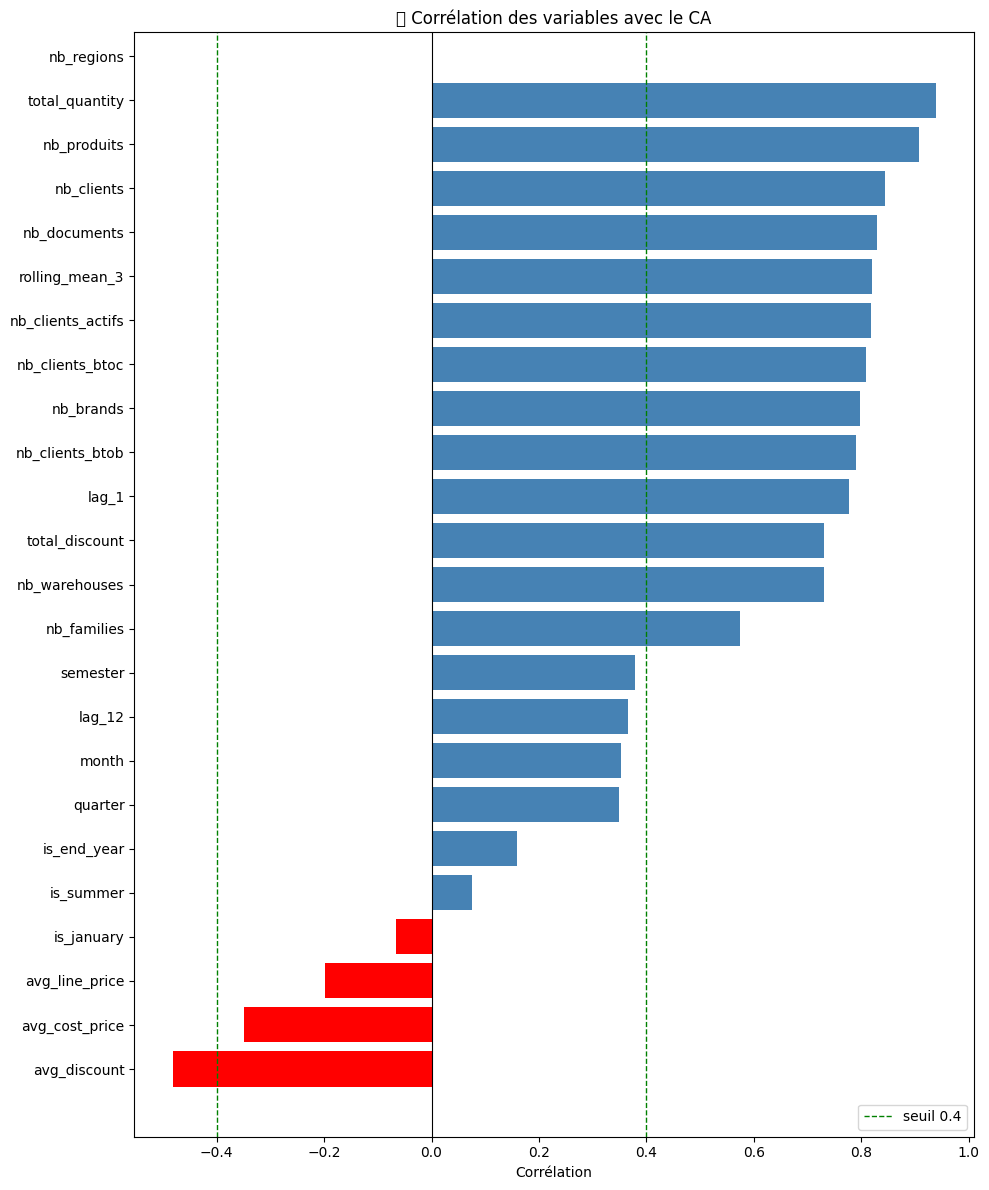


Corrélations :
avg_discount        -0.48
avg_cost_price      -0.35
avg_line_price      -0.20
is_january          -0.07
is_summer            0.08
is_end_year          0.16
quarter              0.35
month                0.35
lag_12               0.37
semester             0.38
nb_families          0.58
nb_warehouses        0.73
total_discount       0.73
lag_1                0.78
nb_clients_btob      0.79
nb_brands            0.80
nb_clients_btoc      0.81
nb_clients_actifs    0.82
rolling_mean_3       0.82
nb_documents         0.83
nb_clients           0.84
nb_produits          0.91
total_quantity       0.94
nb_regions            NaN


In [49]:
TARGET = 'total_sales'

FEATURES = [
    # Temporelles
    'month', 'quarter', 'semester',
    'is_summer', 'is_end_year', 'is_january',
    # Lags
    'lag_1', 'lag_12', 'rolling_mean_3',
    # Métriques base
    'total_quantity', 'nb_documents', 'nb_clients',
    # dim_client
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    # dim_item
    'nb_families', 'nb_brands', 'nb_produits',
    # dim_geographical_area + warehouse
    'nb_regions', 'nb_warehouses',
    # Financières
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]

corr = df_ml[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.4,  color='green', linewidth=1, linestyle='--', label='seuil 0.4')
ax.axvline(-0.4, color='green', linewidth=1, linestyle='--')
ax.set_title('📊 Corrélation des variables avec le CA')
ax.set_xlabel('Corrélation')
ax.legend()
plt.tight_layout()
plt.show()

print('\nCorrélations :')
print(corr.to_string())


In [50]:
tscv       = TimeSeriesSplit(n_splits=4)
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_thresh = []

for thresh in thresholds:
    selected = corr[abs(corr) > thresh].index.tolist()
    if len(selected) < 2:
        continue
    X_all    = df_ml[selected]
    y_all    = df_ml[TARGET]
    sc       = StandardScaler()
    X_sc     = sc.fit_transform(X_all)
    cv_scores = cross_val_score(
        LinearRegression(), X_sc, y_all,
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    mae_cv = -cv_scores.mean()
    results_thresh.append({
        'threshold':   thresh,
        'nb_features': len(selected),
        'features':    selected,
        'MAE_cv':      mae_cv,
    })
    print(f'threshold={thresh} | nb_features={len(selected):>2} | MAE_cv={mae_cv:>10,.0f} DT')

df_thresh = pd.DataFrame(results_thresh)

# ── Sélection automatique du meilleur seuil ──────────────────
best_idx       = df_thresh['MAE_cv'].idxmin()
BEST_THRESHOLD = df_thresh.loc[best_idx, 'threshold']
FEATURES_FINAL = df_thresh.loc[best_idx, 'features']

print(f'\n🏆 Meilleur seuil (automatique) : {BEST_THRESHOLD}')
print(f'   MAE_cv                       : {df_thresh.loc[best_idx, "MAE_cv"]:,.0f} DT')
print(f'   Features ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')

# Toutes les contemporaines possibles
ALL_CONTEMPORAINES = [
    'nb_clients', 'nb_documents', 'total_quantity',
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    'nb_families', 'nb_brands', 'nb_produits',
    'nb_regions', 'nb_warehouses',
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]
CONTEMPORAINES_IN_FEATURES = [f for f in ALL_CONTEMPORAINES if f in FEATURES_FINAL]
print(f'\n   Contemporaines incluses : {CONTEMPORAINES_IN_FEATURES}')

X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]


threshold=0.1 | nb_features=21 | MAE_cv=   101,034 DT
threshold=0.2 | nb_features=19 | MAE_cv=    89,686 DT
threshold=0.3 | nb_features=19 | MAE_cv=    89,686 DT
threshold=0.4 | nb_features=14 | MAE_cv=    98,806 DT
threshold=0.5 | nb_features=13 | MAE_cv=   153,526 DT
threshold=0.6 | nb_features=12 | MAE_cv=   156,173 DT
threshold=0.7 | nb_features=12 | MAE_cv=   156,173 DT

🏆 Meilleur seuil (automatique) : 0.2
   MAE_cv                       : 89,686 DT
   Features (19) : ['avg_discount', 'avg_cost_price', 'quarter', 'month', 'lag_12', 'semester', 'nb_families', 'nb_warehouses', 'total_discount', 'lag_1', 'nb_clients_btob', 'nb_brands', 'nb_clients_btoc', 'nb_clients_actifs', 'rolling_mean_3', 'nb_documents', 'nb_clients', 'nb_produits', 'total_quantity']

   Contemporaines incluses : ['nb_clients', 'nb_documents', 'total_quantity', 'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs', 'nb_families', 'nb_brands', 'nb_produits', 'nb_warehouses', 'avg_discount', 'total_discount', 

In [51]:
df_ml.to_csv('/app/notebooks/ml_dataset.csv', index=False)

with open('/app/notebooks/selected_features.json', 'w') as f:
    json.dump(list(FEATURES_FINAL), f)

with open('/app/notebooks/selected_features.json', 'r') as f:
    print(f'✅ Features sauvegardées : {f.read()}')
print(f'✅ Dataset sauvegardé    : {df_ml.shape}')

✅ Features sauvegardées : ["avg_discount", "avg_cost_price", "quarter", "month", "lag_12", "semester", "nb_families", "nb_warehouses", "total_discount", "lag_1", "nb_clients_btob", "nb_brands", "nb_clients_btoc", "nb_clients_actifs", "rolling_mean_3", "nb_documents", "nb_clients", "nb_produits", "total_quantity"]
✅ Dataset sauvegardé    : (46, 27)


Train : 41 mois (Apr 2022 → Aug 2025)
Test  : 5 mois (Sep 2025 → Jan 2026)


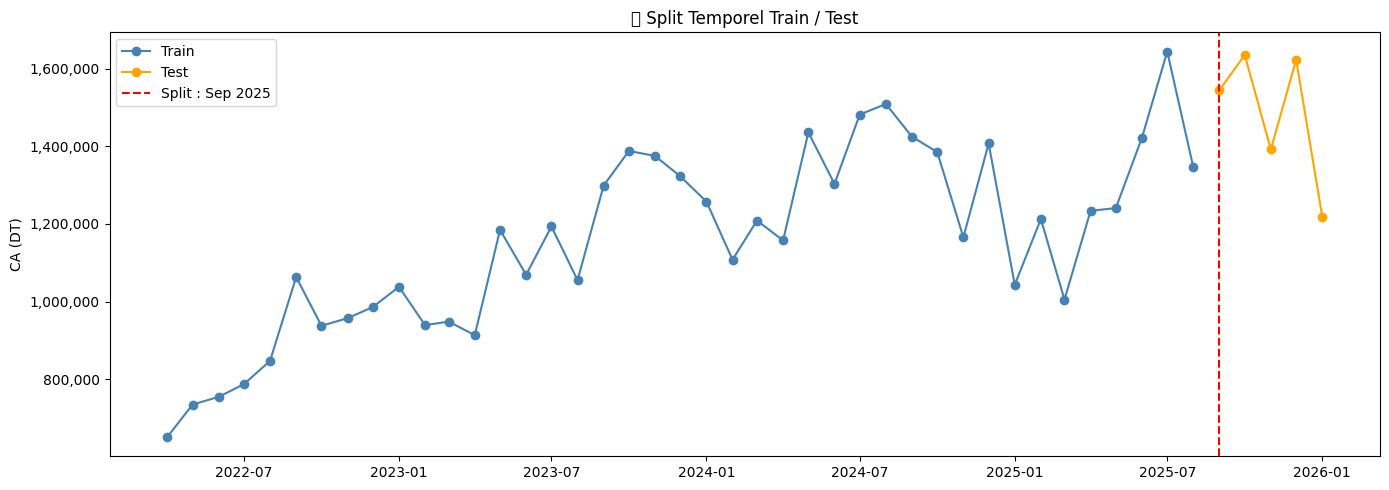

In [52]:
split_idx = int(len(df_ml) * 0.9)
split_date = df_ml.iloc[split_idx]['date']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_train = df_ml.iloc[:split_idx]
df_test  = df_ml.iloc[split_idx:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train)} mois ({df_train["date"].min().strftime("%b %Y")} → {df_train["date"].max().strftime("%b %Y")})')
print(f'Test  : {len(X_test)} mois ({df_test["date"].min().strftime("%b %Y")} → {df_test["date"].max().strftime("%b %Y")})')

fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--', label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [59]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    r2    = r2_score(y_te, pred)
    mape  = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) /
                   (np.abs(y_te) + np.abs(pred))) * 100
    bias  = np.mean(pred - y_te)
    return {
        'name': name, 'model': model, 'pred': pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

from sklearn.ensemble import (GradientBoostingRegressor, ExtraTreesRegressor,
                               AdaBoostRegressor)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor

models_config = [
    # ── Linéaires ─────────────────────────────────────────────
    ('LinearRegression', LinearRegression(),                    X_train_sc, X_test_sc),
    ('Ridge',            Ridge(alpha=10),                       X_train_sc, X_test_sc),
    ('Lasso',            Lasso(alpha=10),                       X_train_sc, X_test_sc),
    ('HuberRegressor',   HuberRegressor(),                      X_train_sc, X_test_sc),

    # ── Bagging ───────────────────────────────────────────────
    ('RandomForest',     RandomForestRegressor(
                            n_estimators=100, max_depth=5,
                            random_state=42),                   X_train,    X_test),
    ('ExtraTrees',       ExtraTreesRegressor(
                            n_estimators=100, max_depth=5,
                            random_state=42),                   X_train,    X_test),

    # ── Boosting ──────────────────────────────────────────────
    ('GBT',              GradientBoostingRegressor(
                            n_estimators=400, max_depth=3,
                            learning_rate=0.03,
                            random_state=42),                   X_train,    X_test),
    ('XGBoost',          XGBRegressor(
                            n_estimators=400, max_depth=3,
                            learning_rate=0.03,
                            random_state=42),                   X_train,    X_test),
    ('AdaBoost',         AdaBoostRegressor(
                            n_estimators=100,
                            learning_rate=0.1,
                            random_state=42),                   X_train,    X_test),
]

results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)

df_results = pd.DataFrame(results).set_index('name')

print('=' * 85)
print(f'{"Modèle":<20} {"MAE":>10} {"RMSE":>10} {"R²":>8} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 85)
for _, row in df_results.iterrows():
    print(f'{row.name:<20} {row["MAE"]:>10,.0f} {row["RMSE"]:>10,.0f} '
          f'{row["R²"]:>8.4f} {row["MAPE"]:>7.2f}% {row["SMAPE"]:>7.2f}% {row["Biais"]:>12,.0f}')
print('=' * 85)

best_name = df_results['MAPE'].idxmin()
print(f'\n🏆 Meilleur modèle : {best_name} (MAPE = {df_results.loc[best_name, "MAPE"]:.2f}%)')

Modèle                      MAE       RMSE       R²     MAPE    SMAPE        Biais
LinearRegression         48,922     54,629   0.8807    3.52%    3.55%        2,053
Ridge                    35,666     43,193   0.9254    2.36%    2.37%       -9,953
Lasso                    48,981     54,505   0.8812    3.53%    3.55%        2,830
HuberRegressor           28,928     38,385   0.9411    1.91%    1.91%        4,124
RandomForest             66,145     73,392   0.7846    4.30%    4.36%      -37,777
ExtraTrees               45,664     47,286   0.9106    3.18%    3.19%      -18,727
GBT                      32,814     40,039   0.9359    2.20%    2.20%       -9,497
XGBoost                  40,765     45,953   0.9156    2.65%    2.68%      -26,080
AdaBoost                 71,717     76,139   0.7682    4.80%    4.85%      -26,159

🏆 Meilleur modèle : HuberRegressor (MAPE = 1.91%)


In [60]:
mape_xgb = df_results.loc['XGBoost', 'MAPE']

pred_train = df_results.loc['XGBoost', 'model'].predict(X_train)

r2_train   = r2_score(y_train, pred_train)
r2_test    = df_results.loc['XGBoost', 'R²']
mape_train = np.mean(np.abs((y_train - pred_train) / y_train)) * 100

print(f'R²   train : {r2_train:.4f}')
print(f'R²   test  : {r2_test:.4f}')
print(f'MAPE train : {mape_train:.2f}%')
print(f'MAPE test  : {mape_xgb:.2f}%')
print(f'\nDifférence R²   : {r2_train - r2_test:.4f}')
print(f'Différence MAPE : {mape_train - mape_xgb:.2f}%')

if r2_train - r2_test > 0.1:
    print('\n⚠️  OVERFITTING détecté !')
else:
    print('\n✅ Pas d\'overfitting significatif')

R²   train : 1.0000
R²   test  : 0.9156
MAPE train : 0.07%
MAPE test  : 2.65%

Différence R²   : 0.0844
Différence MAPE : -2.58%

✅ Pas d'overfitting significatif


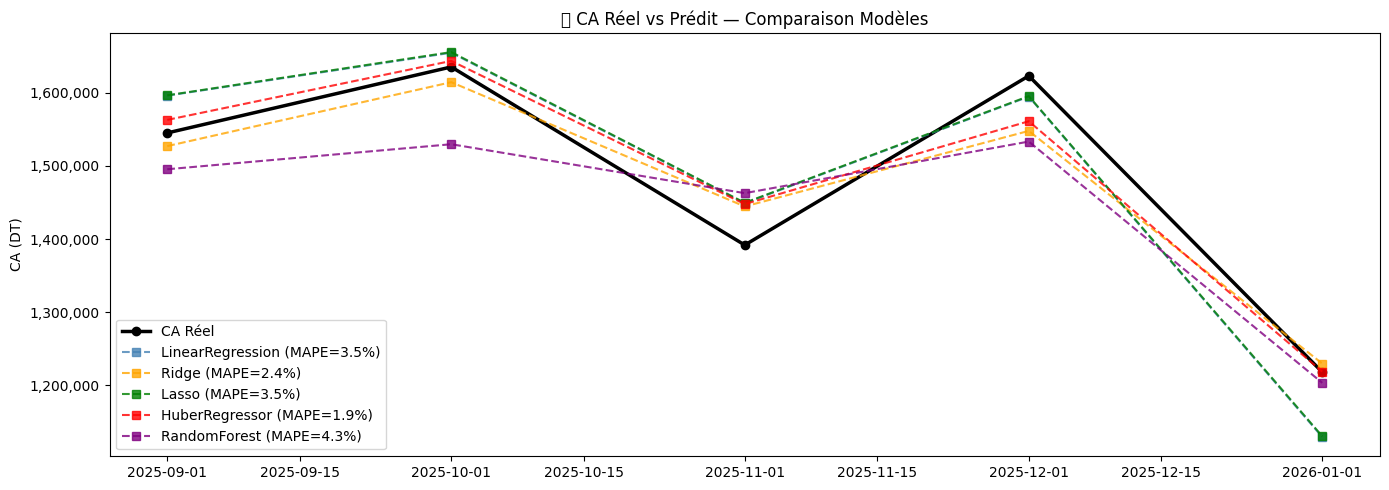

In [61]:
fig, ax = plt.subplots()

ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='black', marker='o', linewidth=2.5)

colors = ['steelblue', 'orange', 'green', 'red', 'purple']
for (_, row), color in zip(df_results.iterrows(), colors):
    ax.plot(df_test['date'], row['pred'],
            label=f"{row.name} (MAPE={row['MAPE']:.1f}%)",
            marker='s', linestyle='--', color=color, alpha=0.8)

ax.set_title('📈 CA Réel vs Prédit — Comparaison Modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [62]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f'=== Détail {best_name} ===\n')
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

=== Détail HuberRegressor ===

      date         reel       predit      ecart  ecart%
2025-09-01 1,545,185.37 1,563,004.73  17,819.35    1.15
2025-10-01 1,635,378.39 1,643,577.16   8,198.77    0.50
2025-11-01 1,391,948.18 1,447,956.89  56,008.71    4.02
2025-12-01 1,623,158.26 1,561,149.48 -62,008.79   -3.82
2026-01-01 1,218,358.52 1,218,961.53     603.01    0.05

Biais : 4,124.21 DT  (surestimation)


Modèle   : HuberRegressor
Départ   : Jan 2026
Objectif : 12 mois suivants

  Feb 2026 →    1,145,188.86 DT
  Mar 2026 →    1,178,586.48 DT
  Apr 2026 →    1,057,357.84 DT
  May 2026 →    1,179,536.77 DT
  Jun 2026 →    1,120,555.79 DT
  Jul 2026 →    1,221,964.48 DT
  Aug 2026 →    1,125,247.99 DT
  Sep 2026 →    1,312,148.60 DT
  Oct 2026 →    1,377,216.18 DT
  Nov 2026 →    1,237,953.02 DT
  Dec 2026 →    1,319,465.40 DT
  Jan 2027 →    1,151,965.84 DT

✅ 12 mois prédits
CA prévisionnel total : 14,427,187.26 DT


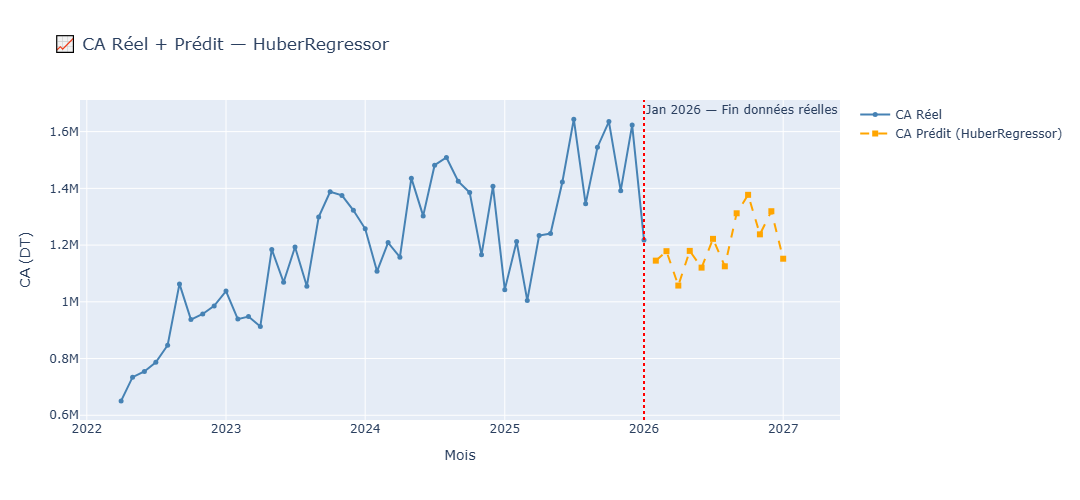


📋 PRÉVISION CA ANNUEL
CA réel 2024       :   15,843,689.48 DT
CA réel 2025       :   16,342,751.14 DT
CA prévu           :   14,427,187.26 DT
Croissance prévue  :          -11.72 %
Modèle             : HuberRegressor
MAPE test          : 1.91%

✅ 12 prédictions écrites dans ClickHouse Gold
      date  year  month  predicted_sales  is_prediction
2026-02-01  2026      2     1,145,188.86              1
2026-03-01  2026      3     1,178,586.48              1
2026-04-01  2026      4     1,057,357.84              1
2026-05-01  2026      5     1,179,536.77              1
2026-06-01  2026      6     1,120,555.79              1
2026-07-01  2026      7     1,221,964.48              1
2026-08-01  2026      8     1,125,247.99              1
2026-09-01  2026      9     1,312,148.60              1
2026-10-01  2026     10     1,377,216.18              1
2026-11-01  2026     11     1,237,953.02              1
2026-12-01  2026     12     1,319,465.40              1
2027-01-01  2027      1     1,151,96

In [63]:
import plotly.graph_objects as go

ALL_CONTEMPORAINES = [
    'nb_clients', 'nb_documents', 'total_quantity',
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    'nb_families', 'nb_brands', 'nb_produits',
    'nb_regions', 'nb_warehouses',
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]
CONTEMPORAINES_IN_FEATURES = [f for f in ALL_CONTEMPORAINES if f in FEATURES_FINAL]

# Réentraîner le meilleur modèle sur tout le dataset
best          = df_results.loc[best_name]
use_scaler    = best_name in ['LinearRegression', 'Ridge']
scaler_final  = StandardScaler()

if use_scaler:
    X_full_sc   = scaler_final.fit_transform(X)
    model_final = type(best['model'])(**best['model'].get_params())
    model_final.fit(X_full_sc, y)
else:
    model_final = type(best['model'])(**best['model'].get_params())
    model_final.fit(X, y)
    scaler_final = scaler

# Variables entières — arrondir
INTEGER_COLS = [
    'nb_clients', 'nb_documents', 'total_quantity',
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    'nb_families', 'nb_brands', 'nb_produits',
    'nb_regions', 'nb_warehouses',
]

df_future = df_ml.copy()
last_date = df_future['date'].max()
all_sales = list(df_future['total_sales'])

print(f'Modèle   : {best_name}')
print(f'Départ   : {last_date.strftime("%b %Y")}')
print(f'Objectif : 12 mois suivants\n')

predictions = []

for i in range(1, 13):
    next_date  = last_date + pd.DateOffset(months=i)
    next_month = next_date.month
    next_year  = next_date.year

    row = {}

    # ── Features temporelles ──────────────────────────────
    if 'year'        in FEATURES_FINAL: row['year']        = next_year
    if 'month'       in FEATURES_FINAL: row['month']       = next_month
    if 'quarter'     in FEATURES_FINAL: row['quarter']     = (next_month - 1) // 3 + 1
    if 'semester'    in FEATURES_FINAL: row['semester']    = 1 if next_month <= 6 else 2
    if 'is_summer'   in FEATURES_FINAL: row['is_summer']   = 1 if next_month in [7, 8] else 0
    if 'is_end_year' in FEATURES_FINAL: row['is_end_year'] = 1 if next_month in [11, 12] else 0
    if 'is_january'  in FEATURES_FINAL: row['is_january']  = 1 if next_month == 1 else 0

    # ── Lag features ─────────────────────────────────────
    if 'lag_1'  in FEATURES_FINAL: row['lag_1']  = all_sales[-1]
    if 'lag_12' in FEATURES_FINAL:
        row['lag_12'] = all_sales[-12] if len(all_sales) >= 12 else np.mean(all_sales)

    # ── Rolling features ──────────────────────────────────
    if 'rolling_mean_3' in FEATURES_FINAL:
        row['rolling_mean_3'] = np.mean(all_sales[-3:])

    # ── Contemporaines → moyenne du même mois ─────────────
    for col in CONTEMPORAINES_IN_FEATURES:
        same_month = df_future[df_future['month'] == next_month][col]
        val = same_month.mean() if len(same_month) > 0 else df_future[col].mean()
        # Arrondir les variables entières
        row[col] = int(round(val)) if col in INTEGER_COLS else val

    # ── Prédiction ────────────────────────────────────────
    X_row = pd.DataFrame([row])[FEATURES_FINAL]
    if use_scaler:
        pred = model_final.predict(scaler_final.transform(X_row))[0]
    else:
        pred = model_final.predict(X_row)[0]

    all_sales.append(pred)
    predictions.append({
        'date':            next_date,
        'year':            next_year,
        'month':           next_month,
        'predicted_sales': pred,
        'is_prediction':   1
    })
    print(f'  {next_date.strftime("%b %Y")} → {pred:>15,.2f} DT')

df_pred = pd.DataFrame(predictions)
print(f'\n✅ {len(df_pred)} mois prédits')
print(f'CA prévisionnel total : {df_pred["predicted_sales"].sum():,.2f} DT')

# ── Visualisation ─────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_ml['date'], y=df_ml['total_sales'],
    name='CA Réel', mode='lines+markers',
    line=dict(color='steelblue', width=2), marker=dict(size=5)
))
fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name=f'CA Prédit ({best_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))
fig.add_vline(
    x=last_date.timestamp() * 1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{last_date.strftime("%b %Y")} — Fin données réelles'
)
fig.update_layout(
    title=f'📈 CA Réel + Prédit — {best_name}',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()

# ── CA annuel ─────────────────────────────────────────────────
ca_prevu   = df_pred['predicted_sales'].sum()
ca_2025    = df_ml[df_ml['date'].dt.year == 2025]['total_sales'].sum()
ca_2024    = df_ml[df_ml['date'].dt.year == 2024]['total_sales'].sum()
croissance = (ca_prevu - ca_2025) / ca_2025 * 100

print('\n' + '=' * 55)
print('📋 PRÉVISION CA ANNUEL')
print('=' * 55)
print(f'CA réel 2024       : {ca_2024:>15,.2f} DT')
print(f'CA réel 2025       : {ca_2025:>15,.2f} DT')
print(f'CA prévu           : {ca_prevu:>15,.2f} DT')
print(f'Croissance prévue  : {croissance:>15.2f} %')
print(f'Modèle             : {best_name}')
print(f'MAPE test          : {best["MAPE"]:.2f}%')
print('=' * 55)

# ── Écriture ClickHouse ───────────────────────────────────────
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)
client2.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    ) ENGINE = MergeTree() ORDER BY date
""")
client2.command('TRUNCATE TABLE gold.ml_predictions')
client2.insert_df('gold.ml_predictions',
    df_pred[['date', 'year', 'month', 'predicted_sales', 'is_prediction']])
check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'\n✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print(check.to_string(index=False))
